In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [24]:
def uniquevalues(arr):
    temp = []
    for x in arr:
        if x not in temp: 
            temp.append(x)
    return temp

In [272]:
# Read data into pd DataFrame
df = pd.DataFrame()



#for chunk in pd.read_csv('C:/Users/burri/Downloads/Center_Source_MiniPET_coinc.dat', delimiter="\t", chunksize=10000):
for chunk in pd.read_csv('C:/Users/burri/Downloads/MiniPET_Test_100mm_15min_coinc.dat', usecols=[2, 3, 4, 7, 8, 9], delimiter="\t", header=None, chunksize=10000):
    chunk.columns = ['TimeL', 'EnergyL', 'IDL', 'TimeR', 'EnergyR', 'IDR']
    chunk['IDL'] = chunk['IDL'] - 896
    chunk['TimeDiff'] = chunk['TimeR'] - chunk['TimeL']
    df = pd.concat([df, chunk], ignore_index=True)
#print(sorted(uniquevalues(df['IDR'])))
print(df)

arr = df.to_numpy()
print(arr)


                  TimeL    EnergyL  IDL            TimeR    EnergyR  IDR  \
0          775837807984   5.985214   23     775837808245  25.784512  110   
1          777665943507  20.723660   84     777665945484   7.040989    4   
2          778363426541  27.935349   99     778363425858  31.255508   29   
3          782518469032  19.400181   42     782518468617  25.686069   89   
4          783639426600  23.217903   86     783639427225  24.344292   39   
...                 ...        ...  ...              ...        ...  ...   
866389  900767938107290  23.676857   89  900767938107103  28.676231   33   
866390  900768097560257  18.752029   47  900768097561545   6.338963   98   
866391  900771186060030   1.104137   66  900771186053945  29.169312    6   
866392  900772963080975   7.960148  102  900772963080671  30.284782   62   
866393  900774264683544   8.694839   93  900774264683972  27.654011   35   

        TimeDiff  
0            261  
1           1977  
2           -683  
3          

In [275]:
print(arr[0])

[7.75837808e+11 5.98521400e+00 2.30000000e+01 7.75837808e+11
 2.57845120e+01 1.10000000e+02 2.61000000e+02]


In [286]:
coincidencesmatrix = [[[] for x in range(128)] for y in range(128)]
# Creates coincidence matrix containing TimeDiffs for every LOR 
for x in range(len(arr)):
    coincidencesmatrix[int(arr[x][2])][int(arr[x][5])].append(arr[x][6])

mastertimediffs = []
# Creates master time difference array
for x in arr:
    mastertimediffs.append(x[6])

0
128


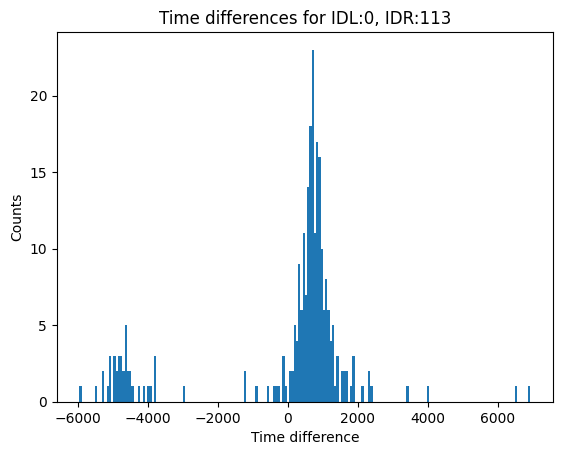

In [312]:
# Takes IDL, IDR, and TimeDiff and returns coincidence location
def getcoinclocation(idl, idr, timediff):
    xL, yL, zL = map[idl]
    xR, yR, zR = map[idr + 128]
    #print(xL, yL, zL)
    #print(xR, yR, zR)
    # Parallel vector to LOR with length equal to light-picosecond in mm
    length = ((xR-xL)**2 + (yR-yL)**2 + (zR-zL)**2)**0.5
    xv = 0.3 * (xR-xL) / length
    yv = 0.3 * (yR-yL) / length
    zv = 0.3 * (zR-zL) / length
    return (xL+xR)/2 + xv*timediff, (yL+yR)/2 + yv*timediff, (zL+zR)/2 + zv*timediff

#print(np.asarray(coincidencesmatrix[0][0]))
#coincs = pd.DataFrame(columns=['x', 'y', 'z'])
coincxs, coincys, coinczs = [], [], []

def gaussian(x, a, mu, c):
    return a * np.exp(-(x - mu)**2 / (2 * c**2))

adjustmatrix = np.asarray([np.asarray([0 for x in range(128)]) for y in range(128)])
mastertimediffsadjusted = []
statisticsthreshold = 0

for l in range(128):
    print(l)
    for r in range(128):
        # If good statistics, make gaussian to find mean for adjustment
        if len(coincidencesmatrix[l][r]) > 100:
            plt.hist(coincidencesmatrix[l][r], bins = 200)
            plt.title(f'Time differences for IDL:{l}, IDR:{r}')
            plt.xlabel('Time difference')
            plt.ylabel('Counts')
            print(len(coincidencesmatrix))
            counts, bins = np.histogram(coincidencesmatrix[l][r], bins = 100)
            inita = 0.8 * np.max(counts)
            initmu = bins[:-1][np.where(counts == np.max(counts))[0][0]]
            try:
                popt = curve_fit(gaussian, bins[:-1], counts, p0 = [inita, initmu, 250])[0]
                if abs(popt[1]) < 10000:
                    adjustmatrix[l][r] = -1 * popt[1]
            except:
                pass

            for timediff in coincidencesmatrix[l][r]:
                #coincs = pd.concat([coincs, pd.DataFrame([np.asarray(getcoinclocation(l, r, timediff))], columns = ['x','y','z'])], ignore_index=True)
                #temp = getcoinclocation(l, r, timediff + adjustmatrix[l][r])
                mastertimediffsadjusted.append(timediff + adjustmatrix[l][r])
                #coincxs.append(temp[0])
                #coincys.append(temp[1])
                #coinczs.append(temp[2])
            break
    break

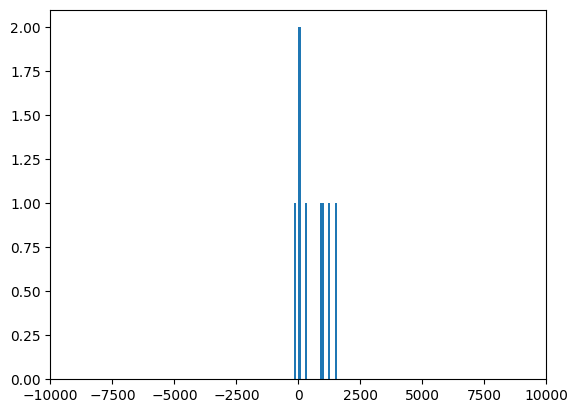

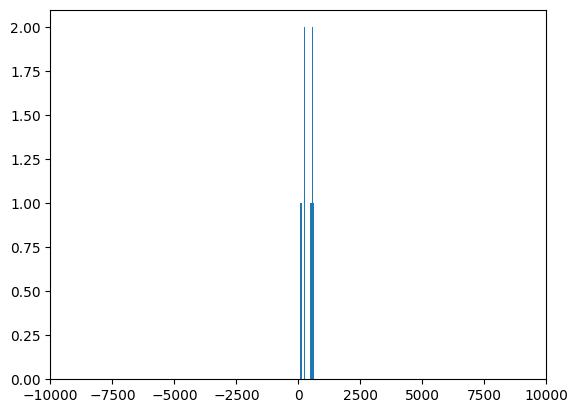

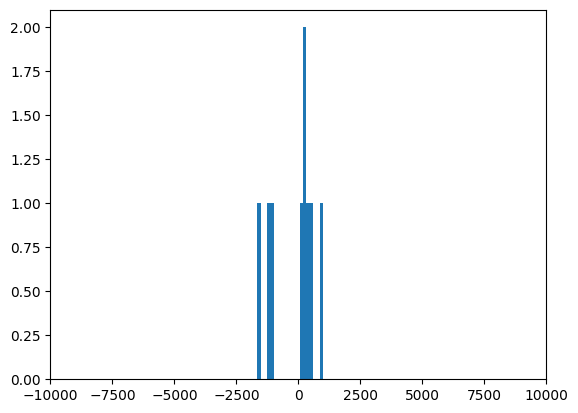

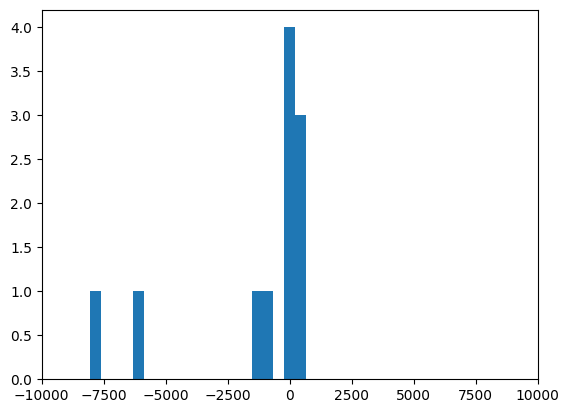

In [ ]:
plt.hist(coincidencesmatrix[0][4], bins = 20)
plt.xlim(-10000, 10000)
plt.show()
plt.hist(coincidencesmatrix[1][2], bins = 20)
plt.xlim(-10000, 10000)
plt.show()
plt.hist(coincidencesmatrix[1][3], bins = 20)
plt.xlim(-10000, 10000)
plt.show()
plt.hist(coincidencesmatrix[7][1], bins = 20)
plt.xlim(-10000, 10000)
plt.show()

In [321]:
print(len(coincidencesmatrix[101][1]))

0


In [ ]:
# Takes IDL, IDR, and TimeDiff and returns coincidence location
def getcoinclocation(idl, idr, timediff):
    xL, yL, zL = map[idl]
    xR, yR, zR = map[idr + 128]
    #print(xL, yL, zL)
    #print(xR, yR, zR)
    # Parallel vector to LOR with length equal to light-picosecond in mm
    length = ((xR-xL)**2 + (yR-yL)**2 + (zR-zL)**2)**0.5
    xv = 0.3 * (xR-xL) / length
    yv = 0.3 * (yR-yL) / length
    zv = 0.3 * (zR-zL) / length
    return (xL+xR)/2 + xv*timediff, (yL+yR)/2 + yv*timediff, (zL+zR)/2 + zv*timediff


adjustmatrix = np.asarray([np.asarray([0 for x in range(128)]) for y in range(128)])
mastertimediffsadjusted = []
statisticsthreshold = 0
pmaccept = 5

for l in range(128):
    print(l)
    for r in range(128):
        # If good statistics, make gaussian to find mean for adjustment
        if len(coincidencesmatrix[l][r]) > statisticsthreshold:
            counts, bins = np.histogram(coincidencesmatrix[l][r], bins = 100)
            maxindex = np.where(counts == np.max(counts))[0][0]
            try:
                adjustmatrix[l][r] = -1 * np.average(bins[maxindex-pmaccept:maxindex+pmaccept+1], weights=counts[maxindex-pmaccept:maxindex+pmaccept+1])
            except:
                adjustmatrix[l][r] = 0

            for timediff in coincidencesmatrix[l][r]:
                #coincs = pd.concat([coincs, pd.DataFrame([np.asarray(getcoinclocation(l, r, timediff))], columns = ['x','y','z'])], ignore_index=True)
                #temp = getcoinclocation(l, r, timediff + adjustmatrix[l][r])
                mastertimediffsadjusted.append(timediff + adjustmatrix[l][r])
                #coincxs.append(temp[0])
                #coincys.append(temp[1])
                #coinczs.append(temp[2])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127


In [307]:
# Create master time difference array
if True:
    master_time_diffs = []
    for x in arr:
        master_time_diffs.append(x[6])

    # Create time difference array after calibration
    master_time_diffs_calibrated = []
    for l in range(128):
        for r in range(128):
            for timediff in coincidences_matrix[l][r]:
                master_time_diffs_calibrated.append(timediff + time_offset_table[l][r])
    
    def gaussian(x, a, mu, c):
        return a * np.exp(-(x - mu)**2 / (2 * c**2))

    # Histogram before time calibration
    hist_before = plt.hist(master_time_diffs, bins = 1000)
    bincenters = [(hist_before[1][x]+hist_before[1][x+1])/2 for x in range(len(hist_before[0]))]
    popt0 = curve_fit(gaussian, bincenters, hist_before[0], p0 = [6000, 0, 1000])[0]
    print(*popt0)
    plt.plot(np.linspace(-3000, 3000, 300), gaussian(np.linspace(-3000, 3000, 300), *popt0))
    plt.xlim(-3000, 3000)
    plt.title('Time differences calibrated')
    plt.xlabel('Time difference (ps)')
    plt.ylabel('Counts')
    plt.show()

NameError: name 'coincidences_matrix' is not defined

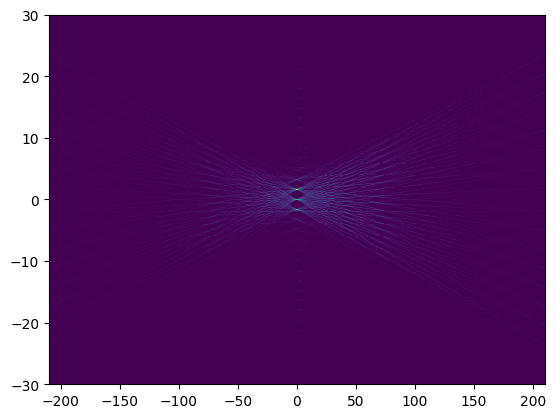

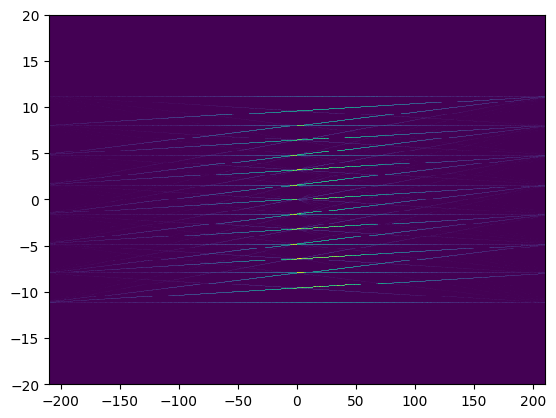

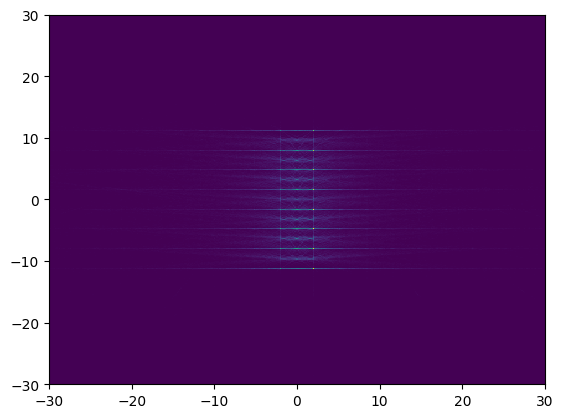

In [233]:


#plt.plot(map.iloc[:,1], map.iloc[:,2], 'o', color = 'black', markersize = 1)

#plt.hist2d(coincs['x'], coincs['y'], range=[[-210, 210], [-50, 50]], bins=100, cmap='viridis')
plt.hist2d(coincxs, coincys, range=[[-210, 210], [-30, 30]], bins=400, cmap='viridis')
plt.show()
plt.hist2d(coincxs, coinczs, range=[[-210, 210], [-20, 20]], bins=400, cmap='viridis')
plt.show()
plt.hist2d(coincys, coinczs, range=[[-30, 30], [-30, 30]], bins=400, cmap='viridis')
plt.show()

In [182]:
print(abs(np.max(mastertimediffs)))
print(abs(np.max(mastertimediffsadjusted)))

9992
17268.213293272875


In [246]:
for row in adjustmatrix:
    print(row)

[-74.49509557362833, -423.15791859653916, 2499.409441154981, 162.77098520211248, 0, 2528.180237199286, -105.9453755580751, 4624.45613178302, 679.353211218818, 0, 553.3083627096995, 0, 0, -61.77343894075923, 5418.264474878624, -659.0290423808775, 1988.1563756544638, -455.38777413420024, 988.7078050807007, 2859.6758760432404, 7179.888642147973, 0, 667.9770926374788, -144.09705014863198, 1223.651625042723, 0, 879.8713730375364, 729.4623940244844, 1031.0002745160027, -570.5870247954365, 546.9876925089262, 924.8627089664433, -1531.4837130340325, 1677.2357190787195, 307.19261684195675, 132.93975879865332, 0, 0, 737.5302634854681, 370.72394599310684, 441.5367212315539, -55.40643355695738, -279.0064678865116, 268.82850250528634, 0, 0, 156.11783764011923, 1184.4109789456702, 0, 5934.038140643784, -96.13170837248994, -1237.0394235203494, -1392.9897816268465, 0, 709.7700349824421, 0, 0, 0, 1008.4916059842117, 0, 0, 2614.377334675222, -1259.1266874542657, -422.5113927886989, -727.680975532507, 0, 

In [71]:
temp = [[[] for x in range(128)] for y in range(128)]
for x in range(128):
    for y in range(128):
        temp[x][y] = len(coincidencesmatrix[x][y])

for x in range(128):
    print(temp[x])

[3, 2, 11, 3, 8, 3, 11, 18, 8, 10, 3, 4, 1, 8, 10, 15, 3, 5, 7, 5, 2, 1, 3, 8, 3, 6, 3, 4, 6, 2, 3, 5, 2, 3, 6, 3, 5, 4, 5, 5, 3, 3, 3, 4, 5, 1, 4, 2, 1, 4, 5, 3, 2, 0, 8, 5, 1, 1, 10, 7, 11, 7, 2, 2, 8, 6, 10, 7, 5, 12, 5, 4, 8, 19, 6, 15, 8, 3, 9, 6, 11, 3, 3, 4, 3, 8, 7, 4, 6, 7, 12, 6, 7, 8, 0, 12, 8, 8, 6, 9, 8, 16, 6, 14, 13, 17, 20, 22, 26, 22, 34, 58, 54, 256, 9, 58, 25, 85, 38, 136, 31, 26, 15, 37, 437, 24, 9, 437]
[12, 7, 10, 9, 7, 5, 8, 15, 8, 8, 5, 6, 1, 12, 11, 17, 7, 5, 3, 3, 3, 2, 2, 1, 1, 5, 5, 3, 2, 5, 2, 3, 4, 0, 5, 4, 8, 2, 4, 2, 4, 3, 4, 3, 5, 4, 3, 5, 4, 5, 2, 3, 5, 5, 3, 7, 4, 5, 6, 3, 5, 4, 6, 5, 7, 9, 13, 5, 19, 5, 12, 7, 6, 35, 5, 22, 16, 8, 11, 3, 7, 6, 8, 4, 7, 8, 7, 7, 11, 5, 2, 19, 13, 8, 0, 14, 20, 19, 11, 35, 10, 16, 9, 21, 15, 36, 33, 47, 24, 58, 34, 245, 180, 844, 19, 463, 31, 395, 124, 227, 40, 41, 15, 102, 851, 83, 12, 971]
[12, 14, 433, 38, 17, 37, 11, 691, 178, 67, 26, 35, 15, 92, 114, 704, 9, 5, 8, 3, 8, 6, 4, 3, 10, 4, 4, 14, 1, 10, 4, 0, 5, 3, 4,

In [ ]:
# Investigate dependence on energy

def linear(x, a, b):
    return a*x + b

# Dataframe containing a, b for both left and right for all channels
functiondf = pd.DataFrame(index=range(128), columns=['aL', 'bL', 'aR', 'bR'])

# Fill Dataframe with a,b parameters
for id in range(128):
    dftemp = df[df['IDL'] == id]
    try:
        poptL = curve_fit(linear, dftemp['EnergyL'], dftemp['TimeDiff'])[0]
    except:
        poptL = (0, 0)
    dftemp = df[df['IDR'] == id]
    try:
        poptR = curve_fit(linear, dftemp['EnergyR'], dftemp['TimeDiff'])[0]
    except:
        poptR = (0, 0)
    functiondf.loc[id] = np.asarray((*poptL, *poptR))

#print(functiondf)

            aL           bL         aR           bR
0    53.918915  -726.779224 -44.017063   -39.438783
1    42.336066  -320.396696 -39.580994   397.215996
2    48.739414  -727.824623 -43.777937   597.729654
3    46.325643  -386.741917 -40.570766  -208.927603
4    55.554493  -347.798175 -39.562465   816.402305
..         ...          ...        ...          ...
123  46.325929  -1975.35452 -44.508855  1944.208077
124  72.882801 -2291.510407 -39.653936  1126.777579
125  82.411463 -2475.437291 -48.955932  1895.961478
126  44.273282 -1626.393876 -46.480642  1435.495554
127  51.283157  -1976.34524 -44.127266  1391.408793

[128 rows x 4 columns]


"\ncurrID = 6\n\ndftemp = df[df['IDL'] == currID]\npopt = curve_fit(linear, dftemp['EnergyL'], dftemp['TimeDiff'])[0]\nprint(popt)\nplt.plot(dftemp['EnergyL'], dftemp['TimeDiff'], 'o', markersize = 0.5, color = 'black')\nplt.plot([0, 35], [linear(0, *popt), linear(35, *popt)])\nplt.title(f'Time difference dependence on energy for channel {currID}')\nplt.xlabel('Energy')\nplt.ylabel('Time difference')\nplt.show()\n\ndftemp = df[df['IDR'] == currID]\npopt = curve_fit(linear, dftemp['EnergyR'], dftemp['TimeDiff'])[0]\nprint(popt)\nplt.plot(dftemp['EnergyR'], dftemp['TimeDiff'], 'o', markersize = 0.5, color = 'black')\nplt.plot([0, 35], [linear(0, *popt), linear(35, *popt)])\nplt.title(f'Time difference dependence on energy for channel {currID}')\nplt.xlabel('Energy')\nplt.ylabel('Time difference')\nplt.show()\n"

[  44.77463558 -210.99589742]


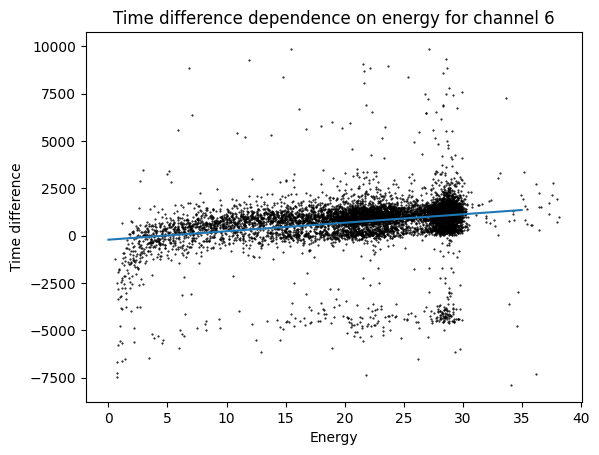

[-38.98200547 906.19465795]


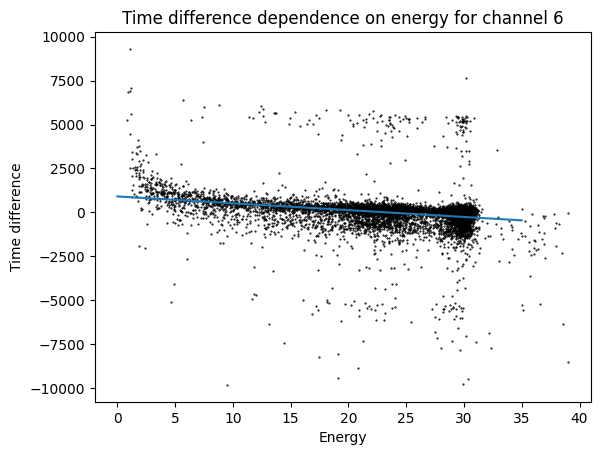

In [251]:

currID = 6

dftemp = df[df['IDL'] == currID]
popt = curve_fit(linear, dftemp['EnergyL'], dftemp['TimeDiff'])[0]
print(popt)
plt.plot(dftemp['EnergyL'], dftemp['TimeDiff'], 'o', markersize = 0.5, color = 'black')
plt.plot([0, 35], [linear(0, *popt), linear(35, *popt)])
plt.title(f'Time difference dependence on energy for channel {currID}')
plt.xlabel('Energy')
plt.ylabel('Time difference')
plt.show()

dftemp = df[df['IDR'] == currID]
popt = curve_fit(linear, dftemp['EnergyR'], dftemp['TimeDiff'])[0]
print(popt)
plt.plot(dftemp['EnergyR'], dftemp['TimeDiff'], 'o', markersize = 0.5, color = 'black')
plt.plot([0, 35], [linear(0, *popt), linear(35, *popt)])
plt.title(f'Time difference dependence on energy for channel {currID}')
plt.xlabel('Energy')
plt.ylabel('Time difference')
plt.show()


In [229]:
coincidencesmatrixwithenergy = [[[] for x in range(128)] for y in range(128)]

# Creates coincidence matrix containing TimeDiffs for every LOR 
for x in range(len(df)):
    coincidencesmatrixwithenergy[df['IDL'][x]][df['IDR'][x]].append((df['TimeDiff'][x], df['EnergyL'][x], df['EnergyR'][x]))


In [243]:
# Use energy function parameters

# Takes IDL, IDR, and returns energy dependent adjustment to be ADDED to timediff
def energyadj(idl, idr, energyL, energyR):
    aL, bL = functiondf.loc[idl][0:2]
    aR, bR = functiondf.loc[idr][2:4]
    return -1 * (aL*energyL + bL + aR*energyR + bR)

coincxsE, coincysE, coinczsE = [], [], []

mastertimediffsadjustedwithenergy = []

for l in range(128):
    print(l)
    for r in range(128):
        for tup in coincidencesmatrixwithenergy[l][r]:
            temp = getcoinclocation(l, r, tup[0] + adjustmatrix[l][r] + energyadj(l, r, tup[1], tup[2]))

            mastertimediffsadjustedwithenergy.append(tup[0] + adjustmatrix[l][r] + energyadj(l, r, tup[1], tup[2]))
            coincxsE.append(temp[0])
            coincysE.append(temp[1])
            coinczsE.append(temp[2])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127


In [250]:
dfrow0 = np.asarray(df.loc[0])
fdfrow0 = np.asarray(functiondf.loc[0])
print(dfrow0)
print(fdfrow0)
print(fdfrow0[0] * dfrow0[1] + fdfrow0[1])

[7.75837808e+11 5.98521400e+00 2.30000000e+01 7.75837808e+11
 2.57845120e+01 1.10000000e+02 2.61000000e+02]
[53.918914612771815 -726.7792235250768 -44.01706277508335
 -39.43878345788164]
-404.06298091991033


6968.411363963928 108.21102259642602 966.3362991358713


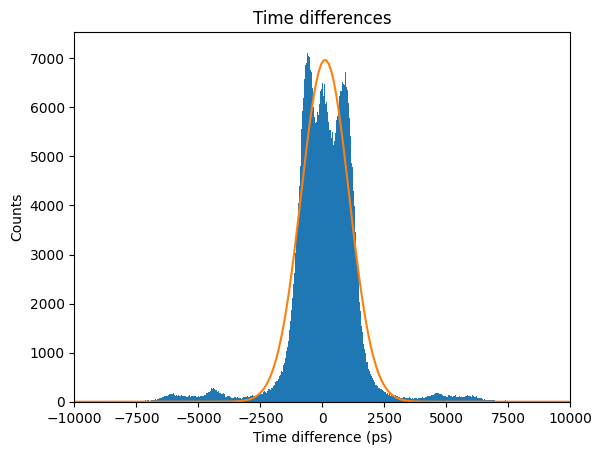

36121.76037966792 50.919042897320196 -234.986561828671


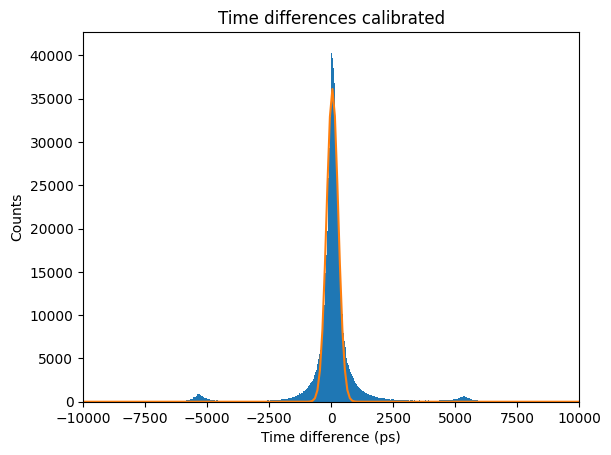

8058.378258445424 -154.4857049456364 1415.3595048662305


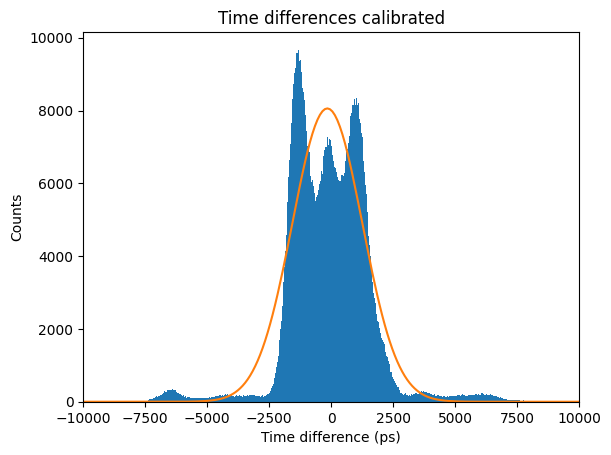

In [263]:
histtimediffs = plt.hist(mastertimediffs, bins = 1000)
popt, pcov = curve_fit(gaussian, histtimediffs[1][:-1], histtimediffs[0], p0 = [6000, 0, 1000])
print(*popt)
plt.plot(np.linspace(-10000, 10000, 200), gaussian(np.linspace(-10000, 10000, 200), *popt))
plt.xlim(-10000, 10000)
plt.title('Time differences')
plt.xlabel('Time difference (ps)')
plt.ylabel('Counts')
plt.show()
histtimediffsadj = plt.hist(mastertimediffsadjusted, bins = 1000)
popt, pcov = curve_fit(gaussian, histtimediffsadj[1][:-1], histtimediffsadj[0], p0 = [6000, 0, 1000])
print(*popt)
plt.plot(np.linspace(-10000, 10000, 200), gaussian(np.linspace(-10000, 10000, 200), *popt))
plt.xlim(-10000, 10000)
plt.title('Time differences calibrated')
plt.xlabel('Time difference (ps)')
plt.ylabel('Counts')
plt.show()


histtimediffsadjE = plt.hist(mastertimediffsadjustedwithenergy, bins = 1000)
popt, pcov = curve_fit(gaussian, histtimediffsadjE[1][:-1], histtimediffsadjE[0], p0 = [6000, 0, 1000])
print(*popt)
plt.plot(np.linspace(-10000, 10000, 200), gaussian(np.linspace(-10000, 10000, 200), *popt))
plt.xlim(-10000, 10000)
plt.title('Time differences calibrated')
plt.xlabel('Time difference (ps)')
plt.ylabel('Counts')
plt.show()